# Figure 10 — phenomenological-scaling validation, for every QPU

Reproduces **Fig. 10** of *"Optimizing resource allocation for accuracy in noisy
variational quantum algorithms"* (Verma et al., arXiv:2606.20153) — but for **all
QPU datasets in `results/hardware/`**, not just IBM Nighthawk.

For each QPU (HVA ansatz, 5-qubit open Heisenberg chain) it draws the three-panel figure:

* **(a)** converged VQE energy $E_\infty$ vs gate count $N_g$ — noiseless (black
  $\diamond$) with the fit $\beta e^{-\kappa N_g}+E_{gs}$, noisy-unmitigated (red
  $\square$), mitigated (blue $\circ$), and the global-depolarizing prediction
  $E_\infty^{fit}=(1-\epsilon_{eff})^{N_g}E_\infty^{noiseless}$ (grey dotted).
* **(b)** residuals of the mitigated floor vs that global-depolarizing model,
  $E_\infty^{mit}-E_\infty^{fit}$ — tests how close the mitigated hardware noise
  is to global-depolarizing.
* **(c)** convergence rate $\mu$ vs $N_g$ (**log–log**, with per-seed error bars) —
  noiseless / mitigated / unmitigated, against the power law $\mu_0 N_g^{-\lambda}$.

**Two on-disk data formats are handled transparently:**

| QPU | source | format |
|-----|--------|--------|
| IBM Nighthawk | `ibm_nighthawk_{baseline,zne}_raw.pkl` | qisk per-seed pickles (the paper's own Fig. 10 data / `plot_v5` inputs) |
| IBM Marrakesh, IonQ Forte, IQM Apollo | `ibm_marrakesh_data.json`, `ionq_forte_data.json`, `iqm_apollo_data.json` | eviden `qpu_fits` (rich `config`+`qpus`, incl. per-seed `seed_data`) |

`fit_mu_trajectory` mirrors `scripts/hardware/qpu_lib.py` so recomputed
quantities match the producer; `fit_mu_powerlaw` is its no-threshold
($N_g^{\rm th}=0$) reduction (offset scan disabled for now).

In [1]:
import json
from pathlib import Path

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# resolve the VQE repo root whether the kernel starts in notebooks/ or VQE/
_here = Path.cwd()
REPO = next(p for p in (_here, *_here.parents) if (p / "results" / "hardware").exists())
HW = REPO / "results" / "hardware"
FIGDIR = REPO / "figures"; FIGDIR.mkdir(exist_ok=True)
print("repo:", REPO)

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": False})

repo: /home/harshit-verma/Desktop/eviden/VQE


## 1. Fit helpers

`fit_mu_trajectory` is copied verbatim (numpy/scipy only) from
`scripts/hardware/qpu_lib.py`. The convergence rate $\mu$ is fit over the paper's
range $N_{it}\le 25\,N_{\rm layers}$ (same as the qisk `plot_v5` reference), the
per-seed spread gives the error bars, and `fit_mu_powerlaw` fits
$\mu=\mu_0 N_g^{-\lambda}$ (no threshold) **weighted by those errors**
(`absolute_sigma`), exactly as in `plot_v5`.

In [2]:
def fit_mu_trajectory(cost_history, E_inf, max_iters=None):
    """Per-iteration decay rate mu from one (E(Nit) - E_inf) trajectory (Eq. 6)."""
    t = np.arange(len(cost_history), dtype=float)
    dE = np.asarray(cost_history, float) - E_inf
    if max_iters is not None:
        t, dE = t[:max_iters], dE[:max_iters]
    valid = dE > 1e-8
    if valid.sum() < 5:
        return np.nan
    try:
        popt, _ = curve_fit(lambda t, a, mu: a * np.exp(-mu * t), t[valid], dE[valid],
                            p0=[max(dE[valid]), 0.05], bounds=([0, 1e-8], [np.inf, 10.0]),
                            maxfev=10000)
        return float(popt[1])
    except RuntimeError:
        return np.nan


def fit_mu_powerlaw(Ng_arr, mu_arr, mu_err=None):
    """mu(Ng) = mu0 * Ng^(-lam)  ->  (mu0, lam, mu0_err, lam_err).

    Threshold N_g^th is fixed to 0 (offset scan disabled for now, per request),
    matching the no-offset form drawn in the paper's Fig. 10(c). When per-seed
    errors `mu_err` are given the fit is weighted by them (absolute_sigma=True),
    exactly as in the qisk plot_v5 reference.
    """
    Ng_arr = np.asarray(Ng_arr, float); mu_arr = np.asarray(mu_arr, float)
    model = lambda Ng, a, b: a * Ng ** (-b)
    valid = np.isfinite(mu_arr) & (mu_arr > 0)
    kw = dict(p0=[1.0, 0.5], bounds=([0, 0], [np.inf, 5.0]), maxfev=10000)
    if mu_err is not None:
        e = np.asarray(mu_err, float); valid &= np.isfinite(e) & (e > 0)
        kw.update(sigma=e[valid], absolute_sigma=True)
    popt, pcov = curve_fit(model, Ng_arr[valid], mu_arr[valid], **kw)
    perr = np.sqrt(np.diag(pcov))
    return float(popt[0]), float(popt[1]), float(perr[0]), float(perr[1])


def series_mu(histories, E_inf, max_iters):
    """Mean/std of mu across seeds, fit over N_it <= max_iters (= 25*N_layers)."""
    mus = np.array([fit_mu_trajectory(h, E_inf, max_iters) for h in histories], float)
    return float(np.nanmean(mus)), float(np.nanstd(mus))

## 2. Loaders → one normalized record per QPU

Both formats are reduced to the same dict of per-layer arrays
(`Ng`, `Einf_{nl,raw,mit}` + std, `mu_{nl,raw,mit}` + std) plus the scalar fit
(`Egs`, `E0INF`=$\beta$, `kappa`, `eps_eff`, `eps_raw`, `mu0`, `lam`, `off`).

* **eviden**: `E0INF/kappa/eps/eps_raw` come from the stored fit; the per-layer
  $E_\infty$/$\mu$ means **and their error bars** are recomputed from the
  per-seed `seed_data`.
* **qisk**: read straight from the per-seed **raw pickles** (`plot_v5` inputs) —
  noiseless + ZNE from the mitigated pkl, unmitigated from the baseline pkl — so
  the $\mu$ error bars come from the same 20 seeds.

For every QPU, $\mu$ is fit per seed over $N_{it}\le 25\,N_{\rm layers}$, and the
power law $\mu=\mu_0 N_g^{-\lambda}$ (threshold fixed to 0) is fit weighted by the
per-seed $\mu$ spread.

In [3]:
def _finalize_mu_fit(out):
    out["mu0"], out["lam"], out["mu0_err"], out["lam_err"] = \
        fit_mu_powerlaw(out["Ng"], out["mu_nl"], out["mu_nl_std"])
    out["off"] = 0.0
    return out


def load_eviden(path):
    d = json.load(open(path))
    qpu_key, rec = next(iter(d["qpus"].items()))
    layers = rec["layers"]; L = [str(l) for l in layers]
    out = {"backend": rec["backend"], "qpu_key": qpu_key, "num_qubits": rec["num_qubits"],
           "layers": layers, "seeds": rec["seeds"], "Ng": np.array([rec["Ng_by_layer"][k] for k in L], float),
           "Egs": rec["delta"], "E0INF": rec["E0INF"], "kappa": rec["kappa"],
           "eps_eff": rec["eps"], "eps_raw": rec["eps_raw"]}
    for src, dst in [("Einf_nl_by_layer", "nl"), ("Einf_raw_by_layer", "raw"),
                     ("Einf_mit_by_layer", "mit")]:
        out[f"Einf_{dst}"] = np.array([rec[src][k] for k in L], float)
    for dst, key in [("nl", "noiseless"), ("raw", "raw"), ("mit", "mitigated")]:
        stds, mus, mustds = [], [], []
        for i, (ld, k) in enumerate(zip(layers, L)):
            sd = rec["seed_data"][k][key]
            stds.append(np.std(sd["finals"]))
            m, ms = series_mu(sd["histories"], out[f"Einf_{dst}"][i], 25 * ld)
            mus.append(m); mustds.append(ms)
        out[f"Einf_{dst}_std"] = np.array(stds)
        out[f"mu_{dst}"] = np.array(mus); out[f"mu_{dst}_std"] = np.array(mustds)
    return _finalize_mu_fit(out)


def load_qisk_pkl(baseline_pkl, zne_pkl):
    """qisk HVA/FakeNighthawk from the per-seed raw pickles (plot_v5 inputs).

    In the baseline (no-ZNE, no-twirl) pickle the unmitigated 'noisy' runs are
    stored under 'mitigated_results'; the ZNE pickle holds noiseless + mitigated.
    """
    import pickle
    base = pickle.load(open(baseline_pkl, "rb")); zne = pickle.load(open(zne_pkl, "rb"))
    nl, mit, raw = zne["noiseless_results"], zne["mitigated_results"], base["mitigated_results"]
    layers = sorted(nl)
    out = {"backend": "FakeNighthawk", "qpu_key": "FakeNighthawk", "num_qubits": 5,
           "layers": layers, "seeds": len(nl[layers[0]]["final_energies"]),
           "Ng": np.array([nl[l]["Ng"] for l in layers], float),
           "Egs": zne["exact_energy"], "E0INF": zne["beta_fit"], "kappa": zne["kappa_fit"],
           "eps_eff": zne["eps_eff"], "eps_raw": base["eps_eff"]}
    for dst, res in [("nl", nl), ("raw", raw), ("mit", mit)]:
        Einf, estd, mu, mustd = [], [], [], []
        for ld in layers:
            fe = np.asarray(res[ld]["final_energies"], float)
            Einf.append(fe.mean()); estd.append(fe.std())
            m, ms = series_mu(res[ld]["cost_histories"], fe.mean(), 25 * ld)
            mu.append(m); mustd.append(ms)
        out[f"Einf_{dst}"] = np.array(Einf); out[f"Einf_{dst}_std"] = np.array(estd)
        out[f"mu_{dst}"] = np.array(mu); out[f"mu_{dst}_std"] = np.array(mustd)
    return _finalize_mu_fit(out)

## 3. Load every QPU

In [4]:
# (display name, loader-thunk).  Add a row here to include another QPU dataset.
QPU_SOURCES = [
    ("IBM Nighthawk", lambda: load_qisk_pkl(HW / "ibm_nighthawk_baseline_raw.pkl",
                                             HW / "ibm_nighthawk_zne_raw.pkl")),
    ("IBM Marrakesh", lambda: load_eviden(HW / "ibm_marrakesh_data.json")),
    ("IonQ Forte",    lambda: load_eviden(HW / "ionq_forte_data.json")),
    ("IQM Apollo",    lambda: load_eviden(HW / "iqm_apollo_data.json")),
]
records = {name: thunk() for name, thunk in QPU_SOURCES}

hdr = f"{'QPU':<15}{'backend':<16}{'nL':>3}{'seeds':>6}{'Egs':>9}{'E0INF':>8}" \
      f"{'kappa':>9}{'eps_eff':>10}{'eps_raw':>10}{'mu0':>9}{'lam':>7}{'off':>6}"
print(hdr); print("-" * len(hdr))
for name, r in records.items():
    print(f"{name:<15}{r['backend']:<16}{len(r['layers']):>3}{r['seeds']:>6}{r['Egs']:>9.3f}"
          f"{r['E0INF']:>8.3f}{r['kappa']:>9.4f}{r['eps_eff']:>10.2e}{r['eps_raw']:>10.2e}"
          f"{r['mu0']:>9.3f}{r['lam']:>7.3f}{r['off']:>6.0f}")

QPU            backend          nL seeds      Egs   E0INF    kappa   eps_eff   eps_raw      mu0    lam   off
------------------------------------------------------------------------------------------------------------
IBM Nighthawk  FakeNighthawk     6    20   -7.712   4.875   0.0060  3.00e-04  7.58e-04   89.350  1.410     0
IBM Marrakesh  FakeMarrakesh     6    20   -7.712   4.851   0.0059  6.29e-04  1.21e-03   91.293  1.406     0
IonQ Forte     IonQForte1        6    20   -7.712   6.190   0.0091  1.19e-03  1.75e-03  151.885  1.577     0
IQM Apollo     IQMFakeApollo     4    10   -7.712   5.883   0.0058  5.50e-03  4.83e-03   11.654  1.026     0


## 4. The Figure-10 plotter

In [5]:
C_NL, C_RAW, C_MIT, C_FIT, C_DEP, C_GS = "k", "#d62728", "#1f77b4", "0.30", "0.55", "m"


def noiseless_curve(r, Ng):
    """Eq. (7): beta e^{-kappa Ng} + Egs."""
    return r["E0INF"] * np.exp(-r["kappa"] * Ng) + r["Egs"]


def depol_curve(r, Ng):
    """Eq. (13): (1 - eps_eff)^Ng * E_inf^noiseless."""
    return (1 - r["eps_eff"]) ** Ng * noiseless_curve(r, Ng)


def _logsafe_yerr(y, err):
    """Asymmetric error bars that never reach <= 0, so a log axis stays sane."""
    y = np.asarray(y, float); err = np.nan_to_num(np.asarray(err, float))
    lower = np.minimum(err, np.where(y > 0, y * 0.999, 0.0))
    return np.vstack([lower, err])


def _tag(ax, s):
    ax.text(0.02, 0.96, s, transform=ax.transAxes, fontsize=13, fontweight="bold",
            va="top", ha="left")


def _nlayers_axis(ax, r):
    top = ax.secondary_xaxis("top")
    top.set_xticks(r["Ng"]); top.set_xticklabels([str(l) for l in r["layers"]], fontsize=8)
    top.set_xlabel(r"$N_{\rm layers}$", fontsize=9)


def plot_fig10(name, r, save=None):
    Ng = r["Ng"]; gg = np.linspace(Ng.min() * 0.92, Ng.max() * 1.03, 400)
    fig = plt.figure(figsize=(13, 6.4))
    gs = fig.add_gridspec(2, 2, width_ratios=[1.3, 1], hspace=0.32, wspace=0.26)
    axa = fig.add_subplot(gs[:, 0]); axb = fig.add_subplot(gs[0, 1]); axc = fig.add_subplot(gs[1, 1])

    # (a) converged energy vs Ng
    axa.axhline(r["Egs"], ls="--", color=C_GS, lw=1.3, label=r"$E_{gs}$")
    axa.plot(gg, noiseless_curve(r, gg), "--", color=C_FIT, lw=1.5,
             label=r"$\beta\,e^{-\kappa N_g}+E_{gs}$")
    axa.plot(gg, depol_curve(r, gg), ":", color=C_DEP, lw=2.0,
             label=r"$(1-\epsilon_{\rm eff})^{N_g}E_\infty^{\rm noiseless}$")
    axa.errorbar(Ng, r["Einf_raw"], yerr=r["Einf_raw_std"], fmt="s--", color=C_RAW,
                 ms=7, capsize=3, lw=1.0, label="Noisy (no mitigation)")
    axa.errorbar(Ng, r["Einf_mit"], yerr=r["Einf_mit_std"], fmt="o-.", color=C_MIT,
                 ms=7, capsize=3, lw=1.0, label="Noisy (mitigated)")
    axa.errorbar(Ng, r["Einf_nl"], yerr=r["Einf_nl_std"], fmt="D-", color=C_NL,
                 ms=6, capsize=3, lw=1.0, label=r"$\epsilon=0$ (noiseless)")
    axa.set_xlabel(r"Number of gates, $N_g$")
    axa.set_ylabel(r"Converged VQE energy, $E_\infty$")
    #axa.legend(fontsize=8.5, loc="upper right"); _tag(axa, "(a)"); _nlayers_axis(axa, r)

    # (b) residual of mitigated floor vs the global-depolarizing model
    resid = r["Einf_mit"] - depol_curve(r, Ng)
    axb.axhline(0, ls=":", color="0.4")
    axb.errorbar(Ng, resid, yerr=r["Einf_mit_std"], fmt="o", color=C_MIT, ms=7, capsize=3)
    axb.set_xlabel(r"Number of gates, $N_g$")
    axb.set_ylabel(r"$E_\infty^{\rm mit}-E_\infty^{\rm fit}$")
    axb.text(0.97, 0.92, rf"$\epsilon_{{\rm eff}}={r['eps_eff']:.2e}$",
             transform=axb.transAxes, ha="right", va="top", fontsize=10)
    #_tag(axb, "(b)")

    # (c) convergence rate mu vs Ng  (log-log, per-seed error bars)
    gc = np.geomspace(Ng.min() * 0.9, Ng.max() * 1.1, 200)
    if np.isfinite(r["mu0"]):
        axc.plot(gc, r["mu0"] * gc ** (-r["lam"]), "-.", color="k", lw=1.4,
                 label=rf"$\mu_0 N_g^{{-\lambda}}$ ($\lambda={r['lam']:.2f}$)")
    axc.errorbar(Ng, r["mu_raw"], yerr=_logsafe_yerr(r["mu_raw"], r["mu_raw_std"]),
                 fmt="s", color=C_RAW, ms=7, capsize=3, label=r"$\mu$ (unmitigated)")
    axc.errorbar(Ng, r["mu_mit"], yerr=_logsafe_yerr(r["mu_mit"], r["mu_mit_std"]),
                 fmt="o", color=C_MIT, ms=7, capsize=3, label=r"$\mu$ (mitigated)")
    axc.errorbar(Ng, r["mu_nl"], yerr=_logsafe_yerr(r["mu_nl"], r["mu_nl_std"]),
                 fmt="D", color=C_NL, ms=6, capsize=3, label=r"$\mu$ (noiseless)")
    axc.set_xscale("log"); axc.set_yscale("log")
    axc.set_xticks(Ng); axc.set_xlim(Ng.min() * 0.88, Ng.max() * 1.12)
    axc.xaxis.set_major_formatter(mticker.ScalarFormatter())
    axc.xaxis.set_minor_formatter(mticker.NullFormatter())
    axc.set_xlabel(r"Number of gates, $N_g$"); axc.set_ylabel(r"$\mu$")
    #axc.legend(fontsize=7.5, loc="lower left"); _tag(axc, "(c)")

    fig.suptitle(f"Fig. 10 validation — {name}  ({r['backend']}, HVA, "
                 f"{r['num_qubits']}-qubit Heisenberg, {r['seeds']} seeds)",
                 fontsize=13, y=0.98)
    if save:
        fig.savefig(save, dpi=130, bbox_inches="tight"); print("saved", save)
    plt.show()

## 5. Figure 10 for every QPU

One 3-panel figure per QPU; each is also written to `figures/fig10_<backend>.png`.

saved /home/harshit-verma/Desktop/eviden/VQE/figures/fig10_FakeNighthawk.png


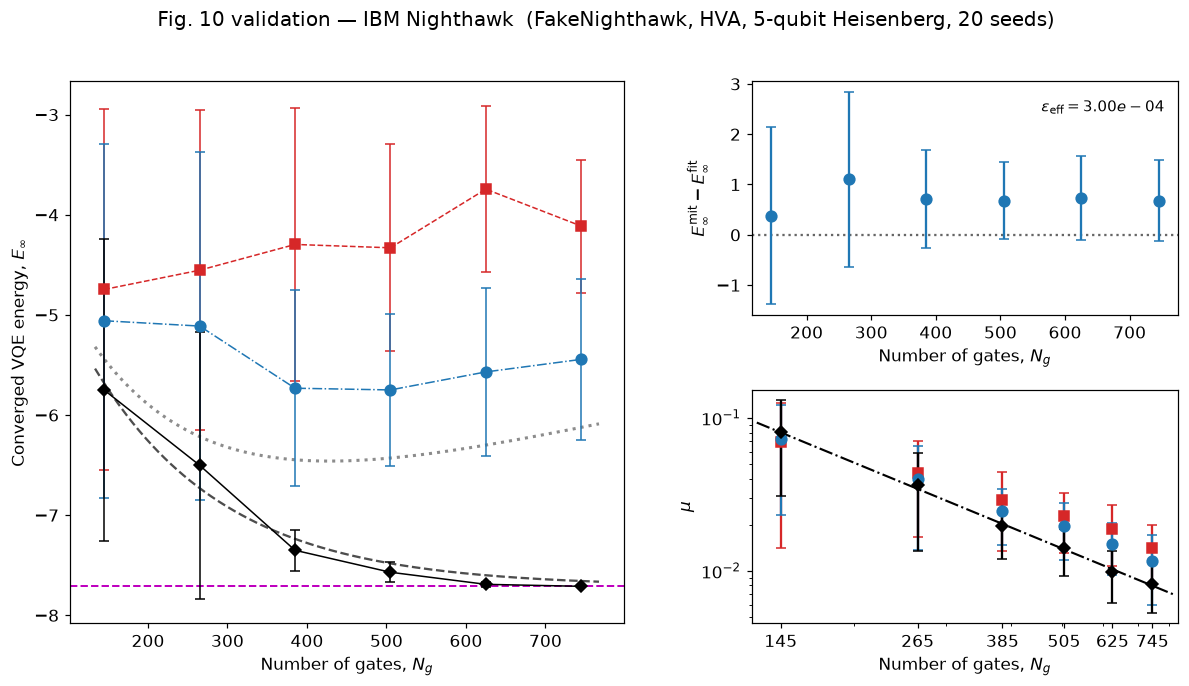

saved /home/harshit-verma/Desktop/eviden/VQE/figures/fig10_FakeMarrakesh.png


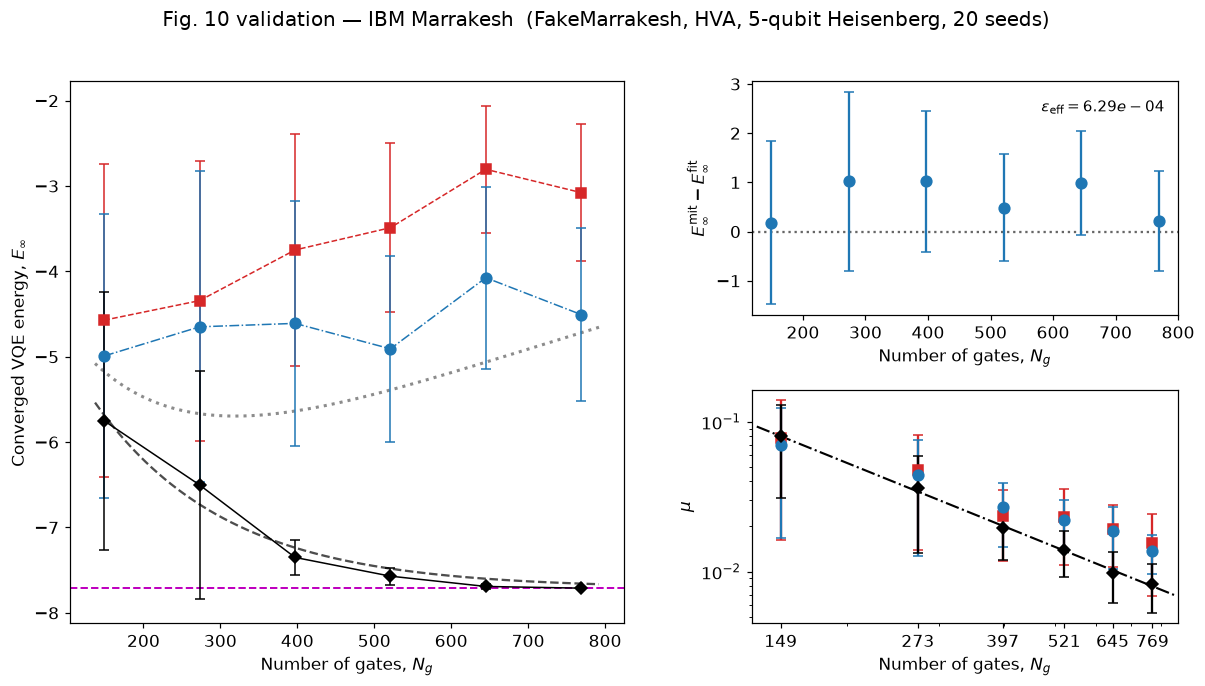

saved /home/harshit-verma/Desktop/eviden/VQE/figures/fig10_IonQForte1.png


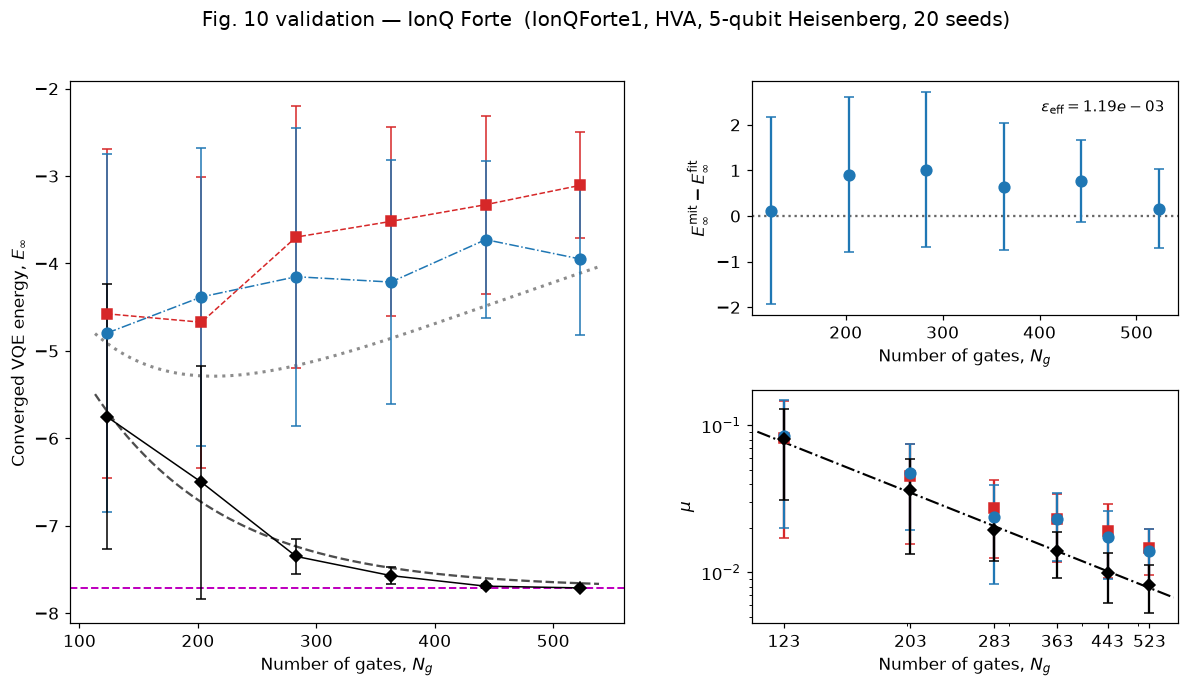

saved /home/harshit-verma/Desktop/eviden/VQE/figures/fig10_IQMFakeApollo.png


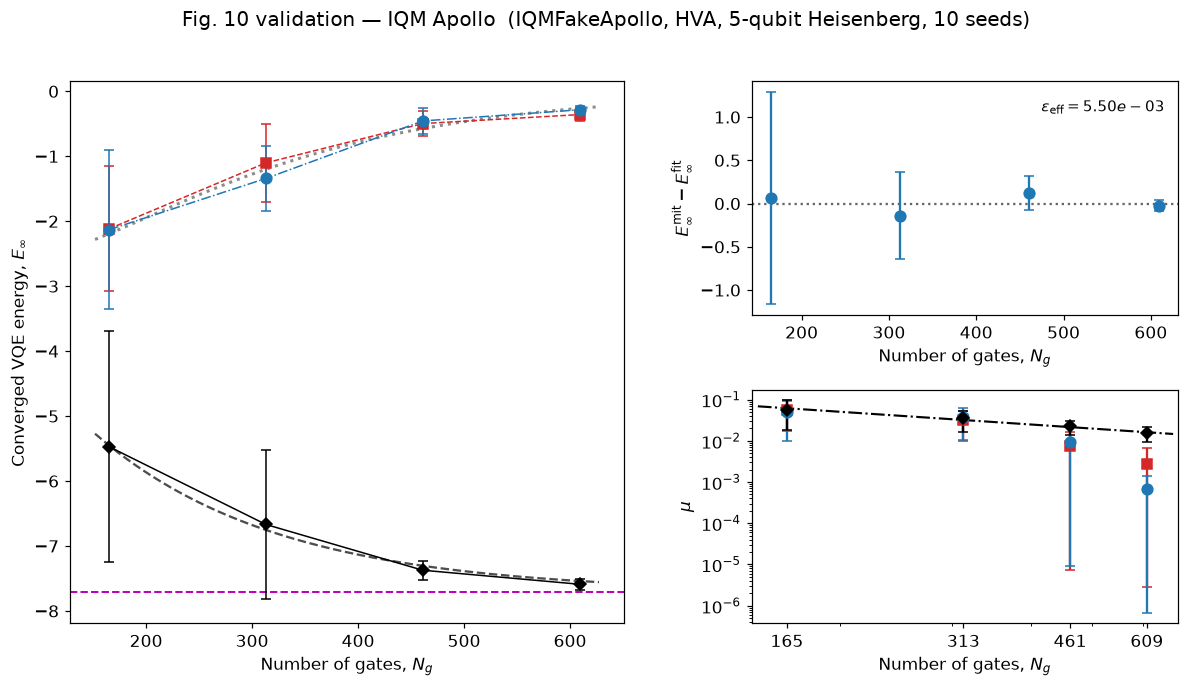

In [6]:
for name, r in records.items():
    plot_fig10(name, r, save=FIGDIR / f"fig10_{r['backend']}.png")

## 6. Cross-QPU summary

A compact comparison of the three headline quantities the figures encode: the
effective noise before/after mitigation ($\epsilon_{\rm raw}$, $\epsilon_{\rm eff}$)
and the best mitigated accuracy actually reached (closest mitigated
$E_\infty^{\rm mit}$ to $E_{gs}$). IQM Apollo sits in the noise-dominated regime
where mitigation yields no gain ($\epsilon_{\rm eff}\gtrsim\epsilon_{\rm raw}$).

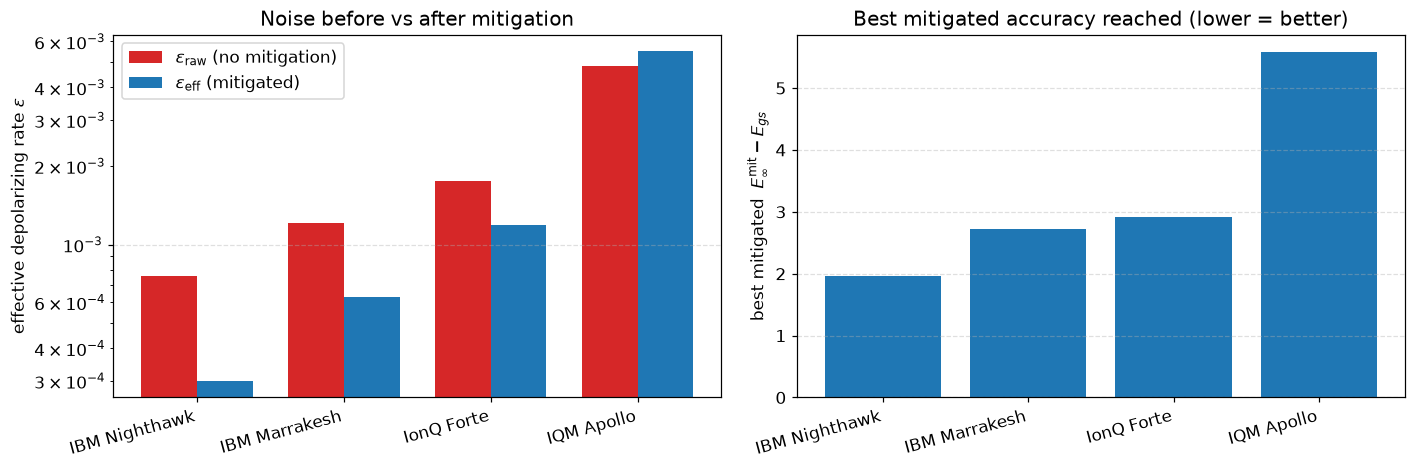

In [7]:
names = list(records)
eps_raw = [records[n]["eps_raw"] for n in names]
eps_eff = [records[n]["eps_eff"] for n in names]
best_gap = [float(np.min(records[n]["Einf_mit"]) - records[n]["Egs"]) for n in names]  # most-negative mit E_inf

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))
x = np.arange(len(names)); w = 0.38
ax1.bar(x - w/2, eps_raw, w, label=r"$\epsilon_{\rm raw}$ (no mitigation)", color="#d62728")
ax1.bar(x + w/2, eps_eff, w, label=r"$\epsilon_{\rm eff}$ (mitigated)", color="#1f77b4")
ax1.set_yscale("log"); ax1.set_ylabel(r"effective depolarizing rate $\epsilon$")
ax1.set_xticks(x); ax1.set_xticklabels(names, rotation=15, ha="right")
ax1.set_title("Noise before vs after mitigation"); ax1.legend(); ax1.grid(axis="y", ls="--", alpha=0.4)

ax2.bar(x, best_gap, color="#1f77b4")
ax2.set_ylabel(r"best mitigated $\;E_\infty^{\rm mit}-E_{gs}$")
ax2.set_xticks(x); ax2.set_xticklabels(names, rotation=15, ha="right")
ax2.set_title("Best mitigated accuracy reached (lower = better)")
ax2.grid(axis="y", ls="--", alpha=0.4)
fig.tight_layout(); fig.savefig(FIGDIR / "fig10_summary_all_qpus.png", dpi=130, bbox_inches="tight")
plt.show()